In [8]:
# fmgraph_examples.ipynb

"""
CASPI FMGraph - Comprehensive Examples
=======================================

This notebook demonstrates the CASPI FMGraph system for complex FM synthesis.

Contents:
1. Simple FM (2 operators)
2. DX7 Algorithm 1 (6-operator cascade)
3. DX7 Algorithm 32 (6 parallel carriers)
4. Custom Algorithm (Diamond topology)
5. Real-time Parameter Control
6. Complex Soundscapes
"""

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import caspy


In [11]:
# ============================================================================
# Setup
# ============================================================================

SAMPLE_RATE = 48000
DURATION = 2.0
NUM_SAMPLES = int(SAMPLE_RATE * DURATION)

def plot_waveform_and_spectrum(audio, title, sample_rate=SAMPLE_RATE):
    """Plot time-domain and frequency-domain representations."""
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Time domain
    samples_to_plot = int(0.01 * sample_rate)
    t = np.arange(samples_to_plot) / sample_rate
    axes[0].plot(t * 1000, audio[:samples_to_plot])
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'{title} - Time Domain (first 10ms)')
    axes[0].grid(True, alpha=0.3)
    
    # Frequency domain
    fft_size = min(len(audio), 8192)
    audio_windowed = audio[:fft_size] * np.hanning(fft_size)
    spectrum = np.fft.fft(audio_windowed)
    freqs = np.fft.fftfreq(fft_size, 1/sample_rate)
    mask = (freqs > 0) & (freqs < 5000)
    magnitude_db = 20 * np.log10(np.abs(spectrum[mask]) + 1e-10)
    
    axes[1].plot(freqs[mask], magnitude_db)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].set_title(f'{title} - Frequency Spectrum')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 5000)
    
    plt.tight_layout()
    plt.show()
    
    return audio

def play_audio(audio, sample_rate=SAMPLE_RATE):
    """Play audio with aggressive clipping."""
    return Audio(audio, rate=sample_rate, autoplay=False)

def visualize_graph_topology(builder, title):
    """Visualize the FM graph topology."""
    connections = builder.get_connections()
    num_ops = builder.get_num_operators()
    outputs = builder.get_output_operators()
    
    print(f"\n{title}")
    print("=" * 70)
    print(f"Operators: {num_ops}")
    print(f"Connections: {len(connections)}")
    print(f"Output Operators: {outputs}")
    print("\nTopology:")
    for conn in connections:
        print(f"  Op{conn.source_operator} → Op{conn.target_operator} "
              f"(depth: {conn.modulation_depth:.2f})")
    print("=" * 70)

Example 1: Simple FM (Modulator → Carrier)

Simple FM Graph
Operators: 2
Connections: 1
Output Operators: [1]

Topology:
  Op0 → Op1 (depth: 3.00)


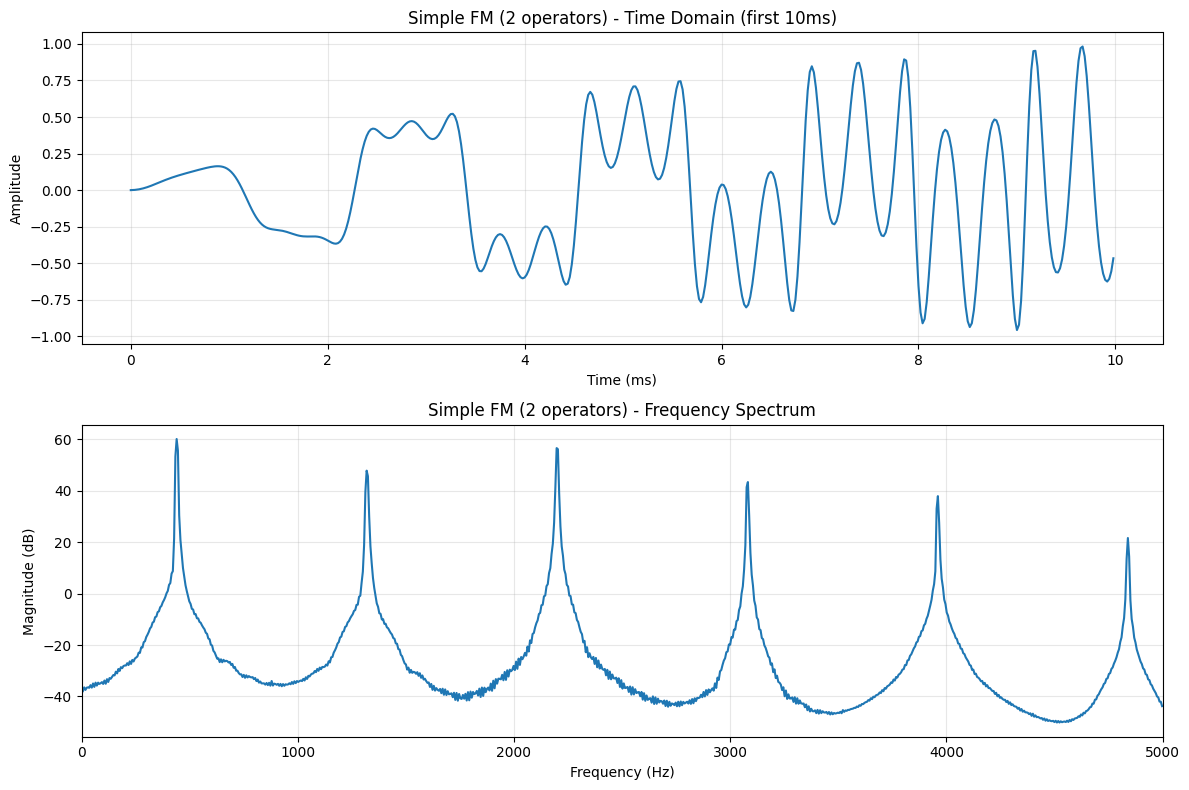

In [12]:
# ============================================================================
# Example 1: Simple FM (2 Operators)
# ============================================================================

print("=" * 70)
print("Example 1: Simple FM (Modulator → Carrier)")
print("=" * 70)

builder1 = caspy.fmgraph.FMGraphBuilder()

mod = builder1.add_operator()
car = builder1.add_operator()

builder1.configure_operator(mod, frequency=880.0, modulation_index=2.0, modulation_depth=1.0)
builder1.configure_operator(car, frequency=440.0, modulation_index=1.0, modulation_depth=1.0)

builder1.connect(mod, car, modulation_depth=3.0)
builder1.set_output_operators([car])

visualize_graph_topology(builder1, "Simple FM Graph")

success, dsp1, error = builder1.compile(sample_rate=SAMPLE_RATE)

if not success:
    print(f"Compilation failed: {error}")
else:
    # Configure envelopes
    for i in range(dsp1.get_num_operators()):
        op = dsp1.get_operator(i)
        op.set_adsr(0.01, 0.1, 0.7, 0.3)
        op.enable_envelope()
    
    dsp1.note_on()
    audio1 = dsp1.render(num_samples=NUM_SAMPLES)
    
    audio1 = plot_waveform_and_spectrum(audio1, "Simple FM (2 operators)")
    display(play_audio(audio1))


Example 2: DX7 Algorithm 1 (6-Operator Cascade)

DX7 Algorithm 1
Operators: 6
Connections: 5
Output Operators: [5]

Topology:
  Op0 → Op1 (depth: 2.00)
  Op1 → Op2 (depth: 2.00)
  Op2 → Op3 (depth: 2.00)
  Op3 → Op4 (depth: 2.00)
  Op4 → Op5 (depth: 2.00)


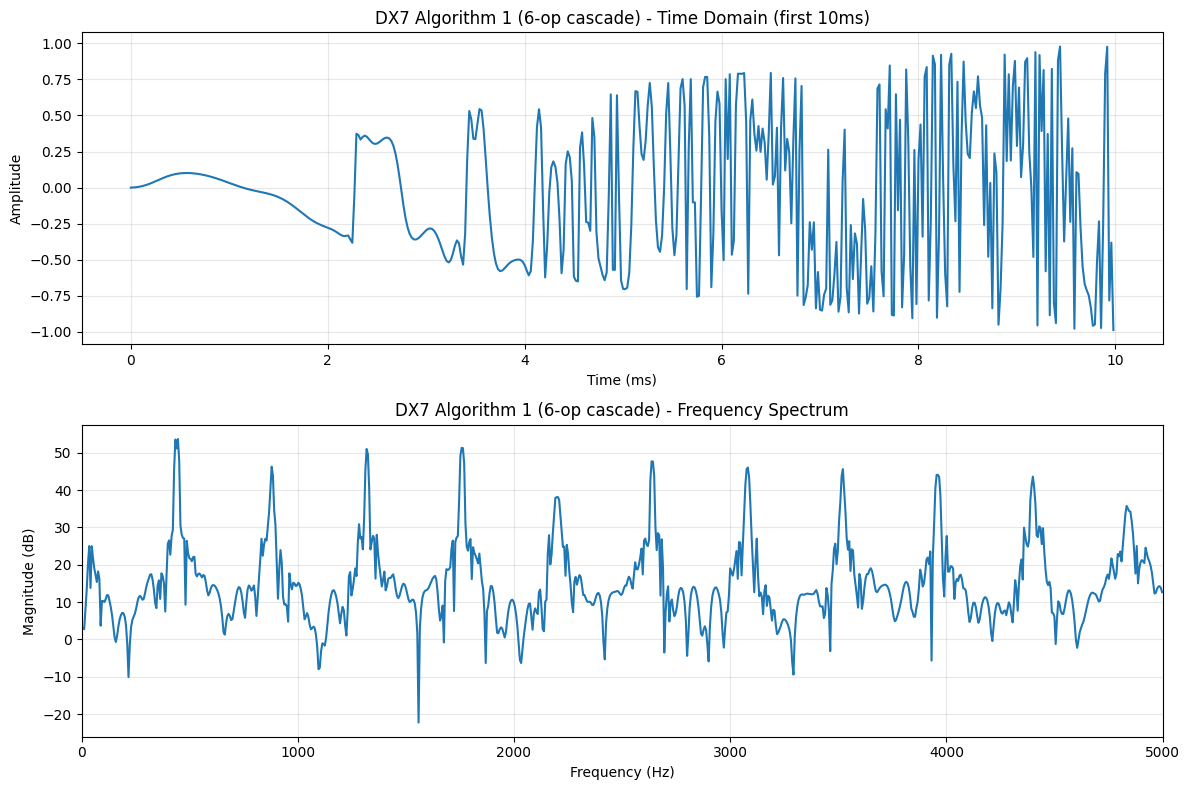


    Algorithm 1 creates very complex, evolving timbres.
    Each operator in the cascade adds more harmonic complexity.
    Notice the rich spectrum with many sidebands.
    


In [13]:
# ============================================================================
# Example 2: DX7 Algorithm 1 (6-Operator Cascade)
# ============================================================================

print("\n" + "=" * 70)
print("Example 2: DX7 Algorithm 1 (6-Operator Cascade)")
print("=" * 70)

builder2 = caspy.fmgraph.FMGraphBuilder()

ops = []
for i in range(6):
    op_idx = builder2.add_operator()
    ops.append(op_idx)
    # Each operator has slightly different modulation index
    builder2.configure_operator(
        op_idx, 
        frequency=440.0, 
        modulation_index=1.0 + i * 0.3, 
        modulation_depth=1.0
    )

# Connect in cascade: 0 → 1 → 2 → 3 → 4 → 5
for i in range(5):
    builder2.connect(ops[i], ops[i+1], modulation_depth=2.0)

builder2.set_output_operators([ops[5]])

visualize_graph_topology(builder2, "DX7 Algorithm 1")

success, dsp2, error = builder2.compile(sample_rate=SAMPLE_RATE)

if success:
    # Configure envelopes with varying decay times
    for i in range(dsp2.get_num_operators()):
        op = dsp2.get_operator(i)
        decay_time = 0.1 + i * 0.05
        op.set_adsr(0.01, decay_time, 0.6, 0.3)
        op.enable_envelope()
    
    dsp2.note_on()
    audio2 = dsp2.render(num_samples=NUM_SAMPLES)
    
    audio2 = plot_waveform_and_spectrum(audio2, "DX7 Algorithm 1 (6-op cascade)")
    display(play_audio(audio2))
    
    print("""
    Algorithm 1 creates very complex, evolving timbres.
    Each operator in the cascade adds more harmonic complexity.
    Notice the rich spectrum with many sidebands.
    """)


Example 3: DX7 Algorithm 32 (6 Parallel Carriers)

DX7 Algorithm 32
Operators: 6
Connections: 0
Output Operators: [0, 1, 2, 3, 4, 5]

Topology:


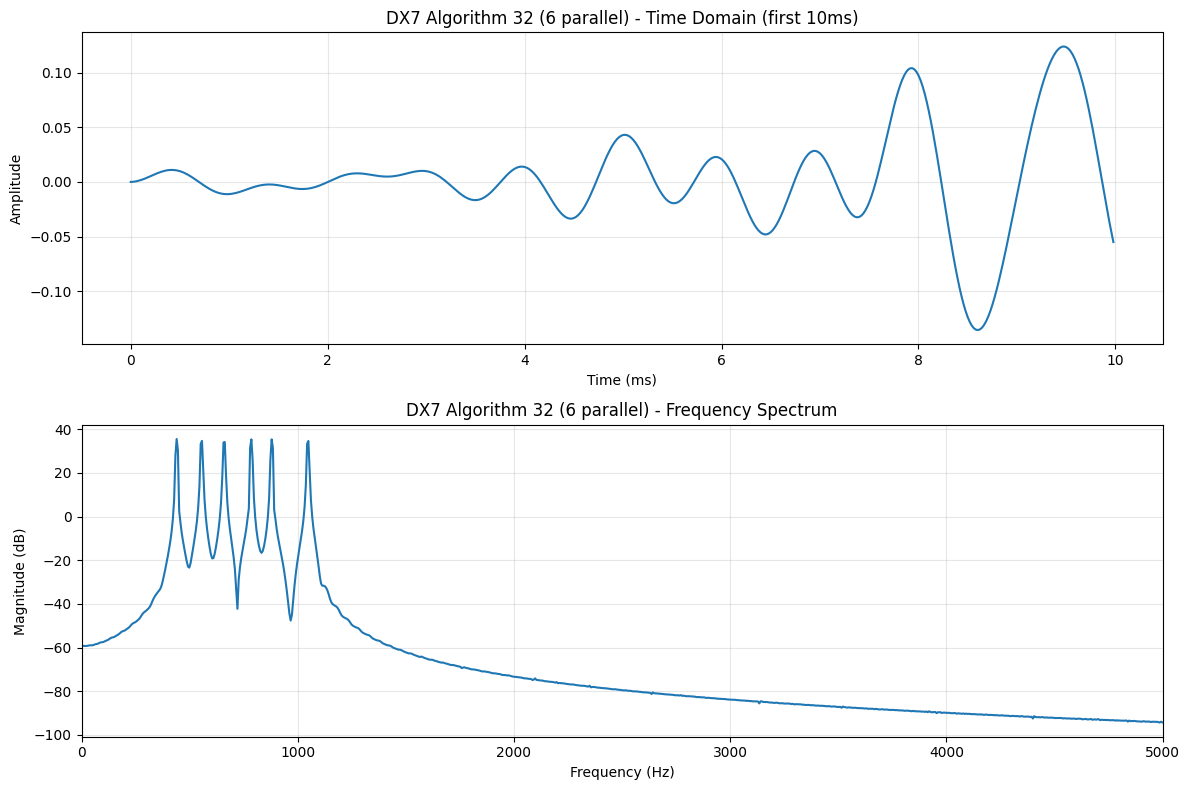


    Algorithm 32 creates harmonic pads and chords.
    Each operator outputs a different frequency.
    Spectrum shows all six fundamental frequencies.
    


In [14]:
# ============================================================================
# Example 3: DX7 Algorithm 32 (6 Parallel Carriers)
# ============================================================================

print("\n" + "=" * 70)
print("Example 3: DX7 Algorithm 32 (6 Parallel Carriers)")
print("=" * 70)

builder3 = caspy.fmgraph.FMGraphBuilder()

ops3 = []
freqs = [440.0, 554.37, 659.26, 783.99, 880.0, 1046.50]  # A4 major chord + octave

for i, freq in enumerate(freqs):
    op_idx = builder3.add_operator()
    ops3.append(op_idx)
    builder3.configure_operator(
        op_idx,
        frequency=freq,
        modulation_index=1.0,
        modulation_depth=0.3  # Lower depth to avoid clipping
    )

# All operators output in parallel (no connections)
builder3.set_output_operators(ops3)

visualize_graph_topology(builder3, "DX7 Algorithm 32")

success, dsp3, error = builder3.compile(sample_rate=SAMPLE_RATE)

if success:
    # Configure envelopes
    for i in range(dsp3.get_num_operators()):
        op = dsp3.get_operator(i)
        op.set_adsr(0.02, 0.15, 0.5, 0.4)
        op.enable_envelope()
    
    dsp3.note_on()
    audio3 = dsp3.render(num_samples=NUM_SAMPLES)
    
    audio3 = plot_waveform_and_spectrum(audio3, "DX7 Algorithm 32 (6 parallel)")
    display(play_audio(audio3))
    
    print("""
    Algorithm 32 creates harmonic pads and chords.
    Each operator outputs a different frequency.
    Spectrum shows all six fundamental frequencies.
    """)



Example 4: Custom Diamond Topology

Diamond Topology
Operators: 4
Connections: 4
Output Operators: [3]

Topology:
  Op0 → Op1 (depth: 2.00)
  Op0 → Op2 (depth: 1.50)
  Op1 → Op3 (depth: 1.00)
  Op2 → Op3 (depth: 1.00)


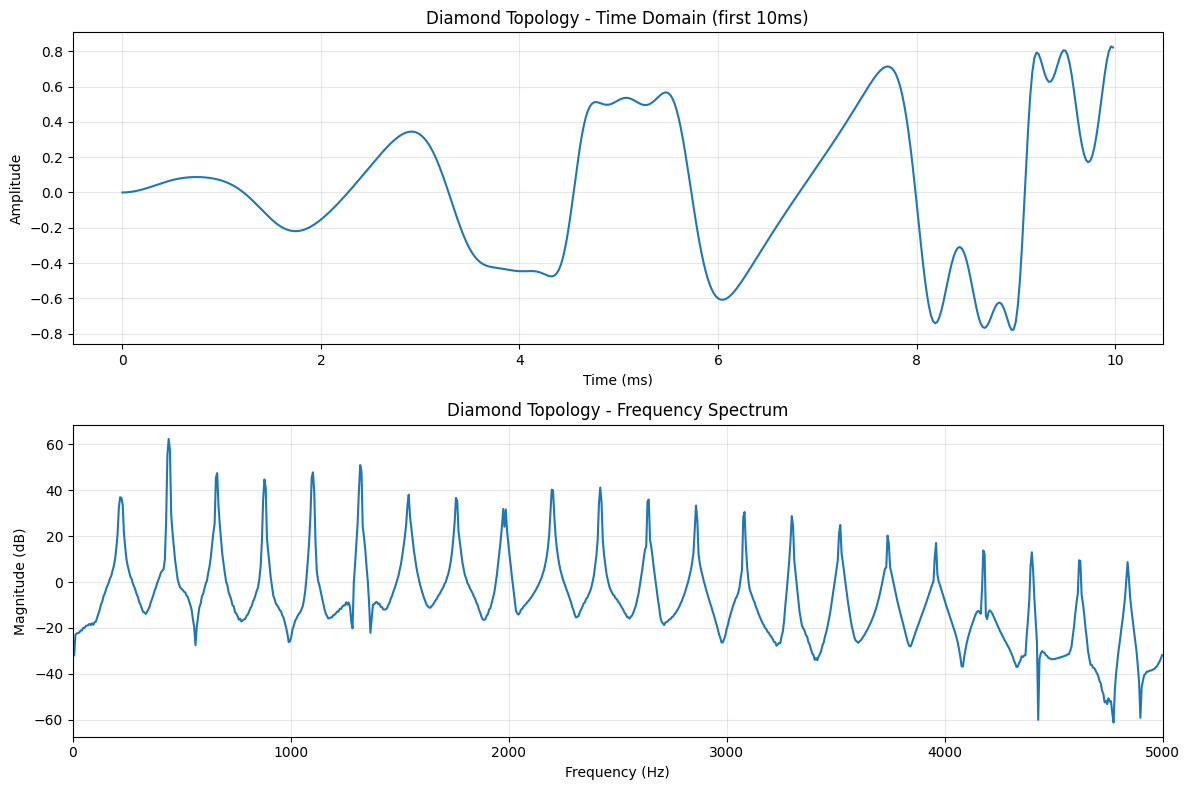


    Diamond topology creates complex interference patterns.
    Two parallel modulation paths converge at the carrier.
    Results in rich, bell-like timbres.
    


In [15]:
# ============================================================================
# Example 4: Custom Algorithm (Diamond Topology)
# ============================================================================

print("\n" + "=" * 70)
print("Example 4: Custom Diamond Topology")
print("=" * 70)

builder4 = caspy.fmgraph.FMGraphBuilder()

# Create diamond: op0 → {op1, op2} → op3
op0 = builder4.add_operator()
op1 = builder4.add_operator()
op2 = builder4.add_operator()
op3 = builder4.add_operator()

builder4.configure_operator(op0, frequency=220.0, modulation_index=3.0, modulation_depth=1.0)
builder4.configure_operator(op1, frequency=440.0, modulation_index=2.0, modulation_depth=1.0)
builder4.configure_operator(op2, frequency=660.0, modulation_index=2.0, modulation_depth=1.0)
builder4.configure_operator(op3, frequency=440.0, modulation_index=1.0, modulation_depth=1.0)

builder4.connect(op0, op1, modulation_depth=2.0)
builder4.connect(op0, op2, modulation_depth=1.5)
builder4.connect(op1, op3, modulation_depth=1.0)
builder4.connect(op2, op3, modulation_depth=1.0)

builder4.set_output_operators([op3])

visualize_graph_topology(builder4, "Diamond Topology")

success, dsp4, error = builder4.compile(sample_rate=SAMPLE_RATE)

if success:
    # Configure envelopes
    for i in range(dsp4.get_num_operators()):
        op = dsp4.get_operator(i)
        op.set_adsr(0.015, 0.12, 0.65, 0.35)
        op.enable_envelope()
    
    dsp4.note_on()
    audio4 = dsp4.render(num_samples=NUM_SAMPLES)
    
    audio4 = plot_waveform_and_spectrum(audio4, "Diamond Topology")
    display(play_audio(audio4))
    
    print("""
    Diamond topology creates complex interference patterns.
    Two parallel modulation paths converge at the carrier.
    Results in rich, bell-like timbres.
    """)



Example 5: Real-time Modulation Depth Sweep


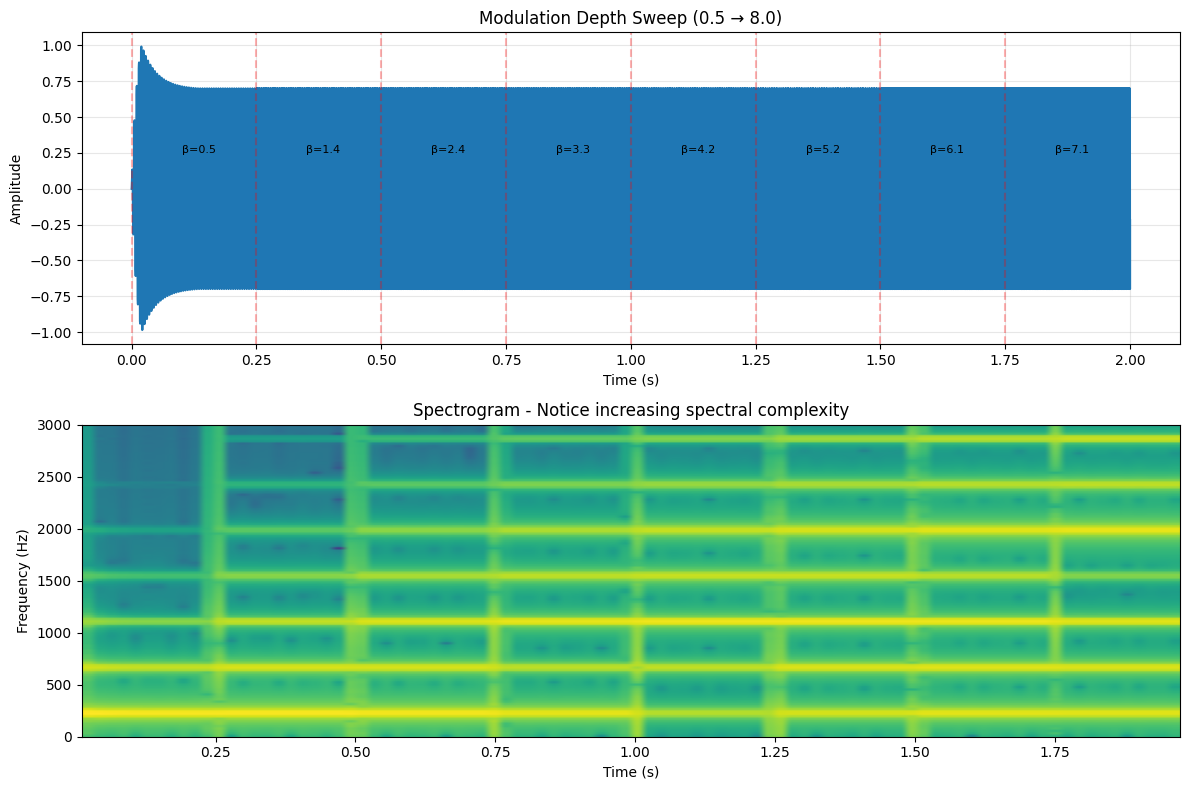


    The modulation depth increases over time.
    Notice how the timbre becomes brighter and more complex.
    The spectrogram shows increasing sideband energy.
    


In [17]:
# ============================================================================
# Example 5: Real-time Parameter Control
# ============================================================================

print("\n" + "=" * 70)
print("Example 5: Real-time Modulation Depth Sweep")
print("=" * 70)

builder5 = caspy.fmgraph.FMGraphBuilder()

mod5 = builder5.add_operator()
car5 = builder5.add_operator()

builder5.configure_operator(mod5, frequency=440.0, modulation_index=2.0, modulation_depth=1.0)
builder5.configure_operator(car5, frequency=220.0, modulation_index=1.0, modulation_depth=1.0)
builder5.connect(mod5, car5, modulation_depth=0.5)  # Start low
builder5.set_output_operators([car5])

success, dsp5, error = builder5.compile(sample_rate=SAMPLE_RATE)

if success:
    # Configure envelopes
    for i in range(dsp5.get_num_operators()):
        op = dsp5.get_operator(i)
        op.set_adsr(0.02, 0.15, 0.7, 0.4)
        op.enable_envelope()
    
    dsp5.note_on()
    
    # Render with modulation depth sweep
    chunk_size = SAMPLE_RATE // 4  # 0.25 seconds per chunk
    num_chunks = 8
    audio5_chunks = []
    
    for chunk_idx in range(num_chunks):
        # Sweep modulation depth from 0.5 to 8.0
        depth = 0.5 + (chunk_idx / num_chunks) * 7.5
        dsp5.set_connection_depth(0, depth)
        
        chunk = dsp5.render(num_samples=chunk_size)
        audio5_chunks.append(chunk)
    
    audio5 = np.concatenate(audio5_chunks)
    
    # Plot with depth annotations
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Time domain
    samples_per_segment = len(audio5) // num_chunks
    t = np.arange(len(audio5)) / SAMPLE_RATE
    axes[0].plot(t, audio5)
    
    for i in range(num_chunks):
        depth_val = 0.5 + (i / num_chunks) * 7.5
        t_pos = i * samples_per_segment / SAMPLE_RATE
        axes[0].axvline(t_pos, color='r', linestyle='--', alpha=0.3)
        axes[0].text(t_pos + 0.1, 0.25, f'β={depth_val:.1f}', fontsize=8)
    
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Modulation Depth Sweep (0.5 → 8.0)')
    axes[0].grid(True, alpha=0.3)
    
    # Spectrogram
    from matplotlib import mlab
    
    spectrum, freqs, t_spec, im = axes[1].specgram(
        audio5, 
        NFFT=2048, 
        Fs=SAMPLE_RATE, 
        noverlap=1024,
        cmap='viridis'
    )
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('Spectrogram - Notice increasing spectral complexity')
    axes[1].set_ylim(0, 3000)
    
    plt.tight_layout()
    plt.show()
    
    display(play_audio(audio5))
    
    print("""
    The modulation depth increases over time.
    Notice how the timbre becomes brighter and more complex.
    The spectrogram shows increasing sideband energy.
    """)


Example 6: Complex Soundscape (Layered Algorithms)


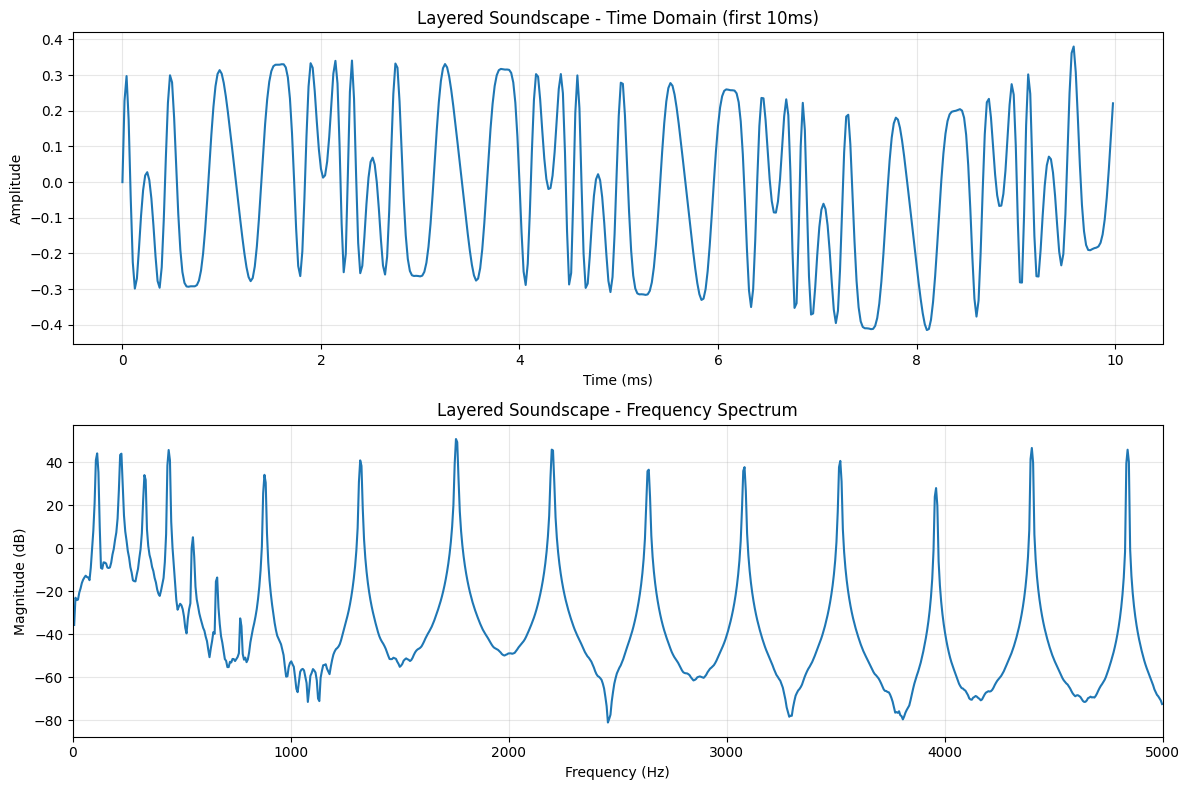


    Multiple FM patches layered together.
    Bell: High-ratio FM for metallic timbre
    Bass: Low-ratio FM for deep fundamental
    

FMGraph Examples Complete!


In [18]:
# ============================================================================
# Example 6: Complex Soundscape (Multiple Voices)
# ============================================================================

print("\n" + "=" * 70)
print("Example 6: Complex Soundscape (Layered Algorithms)")
print("=" * 70)

# Create three different FM patches
def create_bell():
    """DX7-style bell tone."""
    builder = caspy.fmgraph.FMGraphBuilder()
    
    m1 = builder.add_operator()
    m2 = builder.add_operator()
    c = builder.add_operator()
    
    builder.configure_operator(m1, 880.0, 3.0, 1.0)
    builder.configure_operator(m2, 1320.0, 2.5, 1.0)
    builder.configure_operator(c, 440.0, 1.0, 1.0)
    
    builder.connect(m1, c, 4.0)
    builder.connect(m2, c, 2.0)
    builder.set_output_operators([c])
    
    success, dsp, _ = builder.compile(SAMPLE_RATE)
    if success:
        for i in range(dsp.get_num_operators()):
            op = dsp.get_operator(i)
            op.set_adsr(0.001, 0.3, 0.3, 0.5)
            op.enable_envelope()
    return dsp if success else None

def create_bass():
    """Deep bass tone."""
    builder = caspy.fmgraph.FMGraphBuilder()
    
    m = builder.add_operator()
    c = builder.add_operator()
    
    builder.configure_operator(m, 110.0, 2.0, 1.0)
    builder.configure_operator(c, 110.0, 1.0, 1.0)
    builder.connect(m, c, 1.5)
    builder.set_output_operators([c])
    
    success, dsp, _ = builder.compile(SAMPLE_RATE)
    if success:
        for i in range(dsp.get_num_operators()):
            op = dsp.get_operator(i)
            op.set_adsr(0.02, 0.1, 0.8, 0.4)
            op.enable_envelope()
    return dsp if success else None

# Create voices
bell = create_bell()
bass = create_bass()

if bell and bass:
    # Trigger notes at different times
    audio_mix = np.zeros(NUM_SAMPLES)
    
    # Bell hits at 0.0s, 0.5s, 1.0s, 1.5s
    for t in [0.0, 0.5, 1.0, 1.5]:
        bell.reset()
        bell.note_on()
        start_idx = int(t * SAMPLE_RATE)
        bell_chunk = bell.render(num_samples=int(0.8 * SAMPLE_RATE))
        end_idx = min(start_idx + len(bell_chunk), len(audio_mix))
        audio_mix[start_idx:end_idx] += bell_chunk[:end_idx-start_idx] * 0.3
    
    # Bass plays continuously
    bass.note_on()
    bass_audio = bass.render(num_samples=NUM_SAMPLES)
    audio_mix += bass_audio * 0.2
    
    plot_waveform_and_spectrum(audio_mix, "Layered Soundscape")
    display(play_audio(audio_mix))
    
    print("""
    Multiple FM patches layered together.
    Bell: High-ratio FM for metallic timbre
    Bass: Low-ratio FM for deep fundamental
    """)

print("\n" + "=" * 70)
print("FMGraph Examples Complete!")
print("=" * 70)